**Proyecto Final de Diplomado en Machine Learning y Deep Learning Aplicado**

Nombre: Predictor de Compras de Materiales

Datos: Información de Compras Publicas

Etapas del Proceso

1.   Limpieza de los datos recuperados
2.   Verificación de la estructura de los datos
3.   Filtrar por informacion útil
4.   Construcción de Modelo de Regresión






Etapa del modelado ML

1. Analisis Exploratorio
2. Empleo de estategia de Modelo de Regresion
3. Evaluacion de rendimiento
4. Proximas etapas

In [1]:
try:
  from google.colab import drive
  drive.mount('/content/drive/')
  DATA_DIR='/content/drive/MyDrive/Diplomado/Proyecto_Final/contratos'
except ModuleNotFoundError:
  DATA_DIR='.'

print('Entorno OK!')

Mounted at /content/drive/
Entorno OK!


Luego de recuperado los archivos, deben obtenerse la relaciones entre si para unificar los procesos.
Existe una relacion entre si teniendo la primera columna relacionada entre los archivos.
Tambien existen referencias dentro de cada archivo a considerar para poder obtener los valores necesarios para el caso de estudio.
Cargar los registros y limpiar uno por uno para generar el dataset de entrenamiento.

In [2]:
# Ejecutar esta celda primero: carga las tablas
import os
import pandas as pd
YEAR_LEN = 4
#df_res = []

for ruta_actual, subdirectorios, archivos in os.walk(DATA_DIR):
  tiene_archivos = any(archivo.endswith('.csv') for archivo in archivos)

  if tiene_archivos:
    # Actualizamos la variable con la última carpeta encontrada
    print(f'Carpeta actual: {ruta_actual}')

    year = ruta_actual[-YEAR_LEN:]
    #print(year)
    for archivo in archivos:
        print(f' - Archivo: {archivo}')

    # leemos los archivos
    contrato = pd.read_csv(ruta_actual+"/parties.csv")
    items = pd.read_csv(ruta_actual+"/awa_items.csv")
    detalles_adj = pd.read_csv(ruta_actual+"/awards.csv")
    print("Adjudicacion (partes):", len(contrato))
    print("Adjudicacion (detalles):", len(detalles_adj))
    print("Items de contratos:", len(items))

    name_filtered_generic = 'data_merged_' + year + '.csv'

    #filtramos los datos importantes por un criterio
    criterio1 = contrato['compiledRelease/parties/0/identifier/legalName'].str.contains('(ANDE)', case=False, na=False)
    criterio2 = contrato['compiledRelease/parties/0/roles'].str.contains('buyer', case=False, na=False)
    contratos_ande = contrato[criterio1 & criterio2]

    # Extraemos columnas especificas de cada dataframe del csv
    columns_to_extract = ["compiledRelease/id", "compiledRelease/parties/0/name"]
    contratos_selected = contratos_ande[columns_to_extract]

    columns_to_extract2 = ["compiledRelease/id", "compiledRelease/awards/0/date"]
    awards_details_selected = detalles_adj[columns_to_extract2]

    # Convert join keys to category
    contratos_selected["compiledRelease/id"] = contratos_selected["compiledRelease/id"].astype('category')
    awards_details_selected["compiledRelease/id"] = awards_details_selected["compiledRelease/id"].astype('category')

    # Merge with better performance
    mixed_awards_contracts = pd.merge(contratos_selected, awards_details_selected, on='compiledRelease/id', how='left')
    mixed_awards_contracts["compiledRelease/year_compiled"] = year

    # deleting dfs to save memory
    del(contrato)
    del(contratos_ande)
    del(contratos_selected)
    del(awards_details_selected)
    del(detalles_adj)

    #items_filtered = items_selected[items_selected.index.isin()]
    # Process logs in chunks
    #for chunk in pd.read_csv(ruta_actual+"/awa_items.csv", chunksize=500_000):
        #columns_to_extract3 = ["compiledRelease/id", "compiledRelease/awards/0/items/0/classification/description", "compiledRelease/awards/0/items/0/quantity", "compiledRelease/awards/0/items/0/unit/value/amount","compiledRelease/awards/0/items/0/unit/value/currency"]
        #items_selected = chunk[columns_to_extract3]
        #items_selected["compiledRelease/id"] = items_selected["compiledRelease/id"].astype('category')
        # merge the columns
        #mixed_items_contracts = pd.merge(mixed_awards_contracts, items_selected, on='compiledRelease/id', how='left')

    #Process in the same
    columns_to_extract3 = ["compiledRelease/id", "compiledRelease/awards/0/items/0/classification/description", "compiledRelease/awards/0/items/0/quantity", "compiledRelease/awards/0/items/0/unit/value/amount","compiledRelease/awards/0/items/0/unit/value/currency"]
    items_selected = items[columns_to_extract3]
    items_selected["compiledRelease/id"] = items_selected["compiledRelease/id"].astype('category')
    # merge the columns
    mixed_items_contracts = pd.merge(mixed_awards_contracts, items_selected, on='compiledRelease/id', how='inner')

    mixed_items_contracts.to_csv(ruta_actual+'/'+name_filtered_generic)

    # deleting dfs to save memory
    del(items)
    del(items_selected)
    del(mixed_awards_contracts)
    del(mixed_items_contracts)

    #df_res.append(mixed_items_contracts)

#final_res = pd.concat(df_res)
print("Listo. Archivos procesados")


Carpeta actual: /content/drive/MyDrive/Diplomado/Proyecto_Final/contratos/2025
 - Archivo: awa_items.csv
 - Archivo: awards.csv
 - Archivo: parties.csv
 - Archivo: data_merged_2025.csv


/tmp/ipykernel_1848/4079989355.py:21: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  items = pd.read_csv(ruta_actual+"/awa_items.csv")


Adjudicacion (partes): 57283
Adjudicacion (detalles): 16023
Items de contratos: 803858


/tmp/ipykernel_1848/4079989355.py:30: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  criterio1 = contrato['compiledRelease/parties/0/identifier/legalName'].str.contains('(ANDE)', case=False, na=False)
/tmp/ipykernel_1848/4079989355.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  contratos_selected["compiledRelease/id"] = contratos_selected["compiledRelease/id"].astype('category')
/tmp/ipykernel_1848/4079989355.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide

Carpeta actual: /content/drive/MyDrive/Diplomado/Proyecto_Final/contratos/2024
 - Archivo: awa_items.csv
 - Archivo: awards.csv
 - Archivo: parties.csv
 - Archivo: data_merged_2024.csv


...

Carpeta actual: /content/drive/MyDrive/Diplomado/Proyecto_Final/contratos/2016
 - Archivo: awa_items.csv
 - Archivo: awards.csv
 - Archivo: parties.csv
 - Archivo: data_merged_2016.csv


/tmp/ipykernel_1848/4079989355.py:21: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  items = pd.read_csv(ruta_actual+"/awa_items.csv")


Adjudicacion (partes): 88256
Adjudicacion (detalles): 14536
Items de contratos: 220299


/tmp/ipykernel_1848/4079989355.py:30: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  criterio1 = contrato['compiledRelease/parties/0/identifier/legalName'].str.contains('(ANDE)', case=False, na=False)
/tmp/ipykernel_1848/4079989355.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  contratos_selected["compiledRelease/id"] = contratos_selected["compiledRelease/id"].astype('category')
/tmp/ipykernel_1848/4079989355.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide

Listo. Archivos procesados


Luego de procesar por año los conjugamos en uno sólo para reunir los valores

In [3]:
df_res = []

for ruta_actual, subdirectorios, archivos in os.walk(DATA_DIR):
  tiene_archivos = any(archivo.endswith('.csv') for archivo in archivos)

  if tiene_archivos:
    # Actualizamos la variable con la última carpeta encontrada -> name_filtered_generic = 'data_merged_' + year + '.csv'
    print(f'Carpeta actual: {ruta_actual}')
    year = ruta_actual[-YEAR_LEN:]
    name_filtered_generic = 'data_merged_' + year + '.csv'

    # leemos los archivos
    adj_contratos = pd.read_csv(ruta_actual+"/"+name_filtered_generic)
    print("Items de contratos:", len(adj_contratos))

    df_res.append(adj_contratos)

final_res = pd.concat(df_res)
print("Listo. Archivos listo para continuar con análisis.")

Carpeta actual: /content/drive/MyDrive/Diplomado/Proyecto_Final/contratos/2025
Items de contratos: 1629402
Carpeta actual: /content/drive/MyDrive/Diplomado/Proyecto_Final/contratos/2024
Items de contratos: 24337
Carpeta actual: /content/drive/MyDrive/Diplomado/Proyecto_Final/contratos/2023
Items de contratos: 23261
Carpeta actual: /content/drive/MyDrive/Diplomado/Proyecto_Final/contratos/2022
Items de contratos: 9880
Carpeta actual: /content/drive/MyDrive/Diplomado/Proyecto_Final/contratos/2021
Items de contratos: 5527
Carpeta actual: /content/drive/MyDrive/Diplomado/Proyecto_Final/contratos/2020
Items de contratos: 19554
Carpeta actual: /content/drive/MyDrive/Diplomado/Proyecto_Final/contratos/2019
Items de contratos: 20246
Carpeta actual: /content/drive/MyDrive/Diplomado/Proyecto_Final/contratos/2018
Items de contratos: 29155
Carpeta actual: /content/drive/MyDrive/Diplomado/Proyecto_Final/contratos/2017
Items de contratos: 6369
Carpeta actual: /content/drive/MyDrive/Diplomado/Proyect

Una vez obteniendo los valores realizamos el filtro de los items mas relevantes

In [4]:
print("Items de contratos:", len(final_res))
final_res.sample(5)


Items de contratos: 1777400


,Unnamed: 0,compiledRelease/id,compiledRelease/parties/0/name,compiledRelease/awards/0/date,compiledRelease/year_compiled,compiledRelease/awards/0/items/0/classification/description,compiledRelease/awards/0/items/0/quantity,compiledRelease/awards/0/items/0/unit/value/amount,compiledRelease/awards/0/items/0/unit/value/currency
538911,538911,ocds-03ad3f-404496-2025-10-24T10:03:09-04:00,Caja de Jubilaciones y Pensiones del Personal ...,2024-11-26T14:10:24-04:00,2025,Acondicionador de Aire de 60.000 BTU tipo Spli...,7.0,16050000.0,PYG
1300704,1300704,ocds-03ad3f-404496-2025-10-24T10:03:09-04:00,Administración Nacional de Electricidad (ANDE),2024-11-12T12:27:43-04:00,2025,Acondicionador de Aire de 18.000 BTU tipo Spli...,2.0,6250000.0,PYG
1003781,1003781,ocds-03ad3f-404496-2025-10-24T10:03:09-04:00,Administración Nacional de Electricidad (ANDE),2023-09-21T12:45:17-04:00,2025,Acondicionador de Aire de 36.000 BTU de PISO/T...,5.0,14200000.0,PYG
19295,19295,1f02b300-728a-65ce-b24f-5b20bf49be74-1761718979,Administración Nacional de Electricidad (ANDE),2025-09-04T00:00:00-04:00,2025,Motor Diesel,1.0,91491.0,PYG
629256,629256,ocds-03ad3f-404496-2025-10-24T10:03:09-04:00,Caja de Jubilaciones y Pensiones del Personal ...,2025-01-16T09:33:00-04:00,2025,Acondicionador de Aire de 60.000 BTU tipo Spli...,4.0,16000000.0,PYG


Guardamos el parcial del analisis para avanzar con consultas sobre el archivo si se requiere.

In [5]:
final_res.to_csv(DATA_DIR+'/file_filtered_merged.csv')

A partir de los datos obtenidos aplicamos filtros para retirar campos que no revisten utilidad y profundizar el analisis de los datos obtenidos y cuales corresponden a nuestro objeto de estudio.

In [10]:
#mask1 = final_res['compiledRelease/parties/0/name'].str.contains(' (ANDE)', case=False, na=False)
mask1 = final_res['compiledRelease/parties/0/name'].str.contains('Administración Nacional de Electricidad', case=False, na=False)

datased_cleared = final_res[mask1]

print("Items de contratos - Solo Ande:", len(datased_cleared))
datased_cleared.sample(5)

Items de contratos - Solo Ande: 957106


,Unnamed: 0,compiledRelease/id,compiledRelease/parties/0/name,compiledRelease/awards/0/date,compiledRelease/year_compiled,compiledRelease/awards/0/items/0/classification/description,compiledRelease/awards/0/items/0/quantity,compiledRelease/awards/0/items/0/unit/value/amount,compiledRelease/awards/0/items/0/unit/value/currency
1278390,1278390,ocds-03ad3f-404496-2025-10-24T10:03:09-04:00,Administración Nacional de Electricidad (ANDE),2024-10-24T13:59:18-04:00,2025,Acondicionador de Aire de 12.000 BTU tipo Spli...,2.0,5000000.0,PYG
1026593,1026593,ocds-03ad3f-404496-2025-10-24T10:03:09-04:00,Administración Nacional de Electricidad (ANDE),2023-10-03T10:30:50-04:00,2025,Acondicionador de Aire de 18.000 BTU tipo Spli...,2.0,6650000.0,PYG
817721,817721,ocds-03ad3f-404496-2025-10-24T10:03:09-04:00,Administración Nacional de Electricidad (ANDE),2022-05-24T15:12:16-04:00,2025,Acondicionador de Aire de 24.000 BTU tipo Spli...,1.0,7649000.0,PYG
1544595,1544595,ocds-03ad3f-404496-2025-10-24T10:03:09-04:00,Administración Nacional de Electricidad (ANDE),2025-09-02T15:09:08-04:00,2025,Acondicionador de Aire de 60.000 BTU tipo Spli...,6.0,24500000.0,PYG
1132196,1132196,ocds-03ad3f-404496-2025-10-24T10:03:09-04:00,Administración Nacional de Electricidad (ANDE),2023-12-12T15:16:17-04:00,2025,Acondicionador de Aire de 36.000 BTU de PISO/T...,1.0,18000000.0,PYG


Solamente obtenemos los datos relevantes para mantener un dataset consistente. Para evitar ambigüedad en el filtro anterior sólo retuvimos datos de una entidad

In [11]:
#datased_cleared = final_res.copy()
dataset_cleared = datased_cleared.drop(['compiledRelease/id', 'compiledRelease/parties/0/name', 'Unnamed: 0'], axis=1)
dataset_cleared.rename(columns={'compiledRelease/awards/0/items/0/classification/description': 'item', 'compiledRelease/awards/0/items/0/quantity': 'quantity',
                                 'compiledRelease/awards/0/date': 'date_awards','compiledRelease/awards/0/items/0/unit/value/amount': 'amount',
                                'compiledRelease/awards/0/items/0/unit/value/currency': 'currency', 'compiledRelease/year_compiled': 'year_compiled'}, inplace=True)


Una vez obtenido los resultados, verificamos

In [12]:
print(dataset_cleared.columns)
dataset_cleared.head()

Index(['date_awards', 'year_compiled', 'item', 'quantity', 'amount',
       'currency'],
      dtype='object')


,date_awards,year_compiled,item,quantity,amount,currency
0,2022-10-26T12:00:00-04:00,2025,Transformador de distribucion monofasico,1200.0,8627520.0,PYG
1,2022-10-26T12:00:00-04:00,2025,Transformador de distribucion trifasico,800.0,31482880.0,PYG
2,2022-10-26T12:00:00-04:00,2025,Transformador de distribucion trifasico,1800.0,20925520.0,PYG
3,2022-10-26T12:00:00-04:00,2025,Transformador de distribucion monofasico,1800.0,8627520.0,PYG
4,2022-10-26T12:00:00-04:00,2025,Transformador de distribucion trifasico,1200.0,31482880.0,PYG


In [13]:
print("Items de contratos de ANDE:", len(dataset_cleared))


Items de contratos de ANDE: 957106


Verificamos cuales son los tipo de items solicitados y solo para retener aquellos mas recurrentes

In [14]:
items_mas_pedidos = dataset_cleared["item"].value_counts() #("quantity")
items_mas_pedidos.head(20)

,count
item,
Acondicionador de Aire de 24.000 BTU tipo Split de pared frío/calor,214236
Acondicionador de Aire de 18.000 BTU tipo Split de pared frío/calor,213154
Acondicionador de Aire de 12.000 BTU tipo Split de pared frío/calor,147152
Acondicionador de Aire de 60.000 BTU tipo Split PISO/TECHO - frío/calor Condensador horizontal,89806
Acondicionador de Aire de 36.000 BTU de PISO/TECHO - frío/calor– Condensador horizontal,81150
Mantenimiento y reparacion de instalaciones electricas,46388
Acondicionador de Aire de 48.000 BTU tipo Split de PISO/TECHO - frío/calor - Condensador horizontal,29214
Ampliacion de red electrica,18189
Motor Diesel,12335


In [45]:
# Agrupar por año e ítem, y sumar las cantidades
#items_grouped = (dataset_cleared.groupby(["year_compiled", "item"], as_index=False)["quantity"].sum())
items_grouped = (dataset_cleared.groupby(["year_compiled", "item"]).size().reset_index(name="order_count"))

# Obtener el ítem más pedido por cada año
#top_items = items_grouped.loc[items_grouped.groupby("year_compiled")["quantity"].idxmax()]
top_items_by_freq = items_grouped.loc[items_grouped.groupby("year_compiled")["order_count"].idxmax()].head(10)

print(top_items_by_freq)

      year_compiled                                               item  \
15             2016                        Ampliacion de red electrica   
403            2017                        Ampliacion de red electrica   
1145           2018                      Servicio de despacho aduanero   
1445           2019  Mantenimiento y reparacion de instalaciones el...   
1797           2020  Mantenimiento y reparacion de instalaciones el...   
2245           2021                                   Servicio de poda   
2483           2022  Mantenimiento y reparacion de instalaciones el...   
2788           2023  Mantenimiento y reparacion de instalaciones el...   
2915           2024                        Ampliacion de red electrica   
3348           2025  Acondicionador de Aire de 24.000 BTU tipo Spli...   

      order_count  
15           5011  
403          2466  
1145         3125  
1445        12886  
1797        13376  
2245         1664  
2483         1986  
2788        14877  
2915 

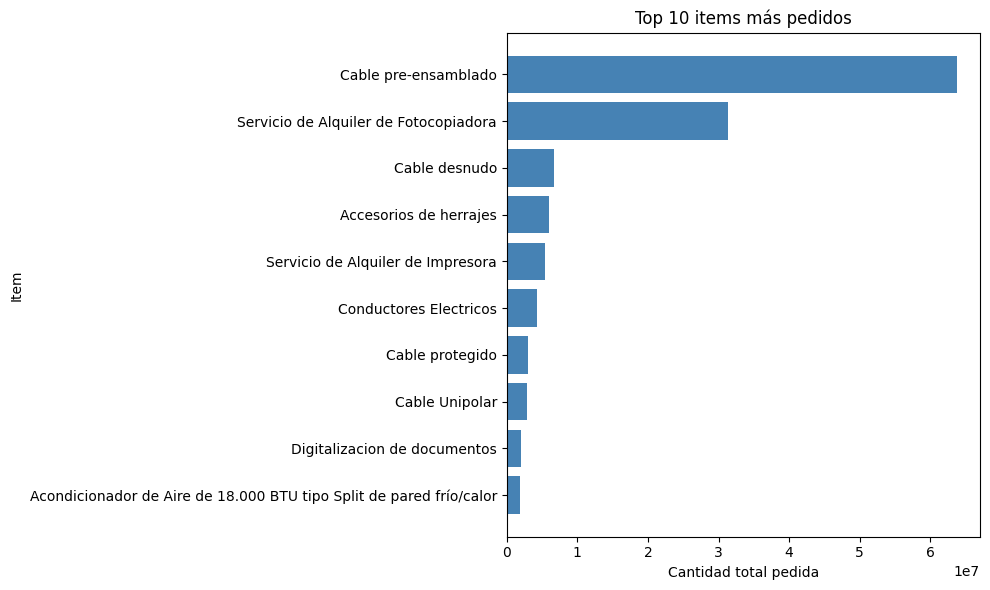

In [47]:
import matplotlib.pyplot as plt

# Contar la cantidad de pedidos por item (ajustá 'item' y 'quantity' a tus columnas reales)
top_items_by_freq = dataset_cleared.groupby('item')['quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_items_by_freq.index, top_items_by_freq.values, color='steelblue')
plt.xlabel('Cantidad total pedida')
plt.ylabel('Item')
plt.title('Top 10 items más pedidos')
plt.gca().invert_yaxis()  # Para que el más pedido quede arriba
plt.tight_layout()
plt.show()

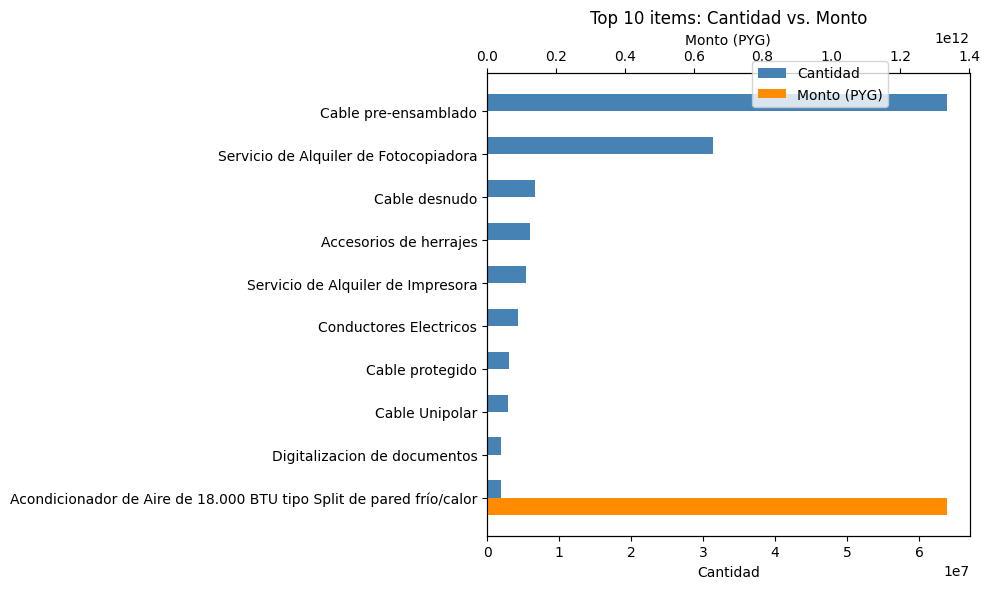

In [48]:
import numpy as np

resumen = dataset_cleared.groupby('item').agg(cantidad=('quantity', 'sum'), monto=('amount', 'sum')).sort_values('cantidad', ascending=False).head(10)

fig, ax1 = plt.subplots(figsize=(10, 6))

x = np.arange(len(resumen))
width = 0.4

ax1.barh(x - width/2, resumen['cantidad'], height=width, color='steelblue', label='Cantidad')
ax1.set_yticks(x)
ax1.set_yticklabels(resumen.index)
ax1.invert_yaxis()
ax1.set_xlabel('Cantidad')

ax2 = ax1.twiny()
ax2.barh(x + width/2, resumen['monto'], height=width, color='darkorange', label='Monto (PYG)')
ax2.set_xlabel('Monto (PYG)')

fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))
plt.title('Top 10 items: Cantidad vs. Monto')
plt.tight_layout()
plt.show()

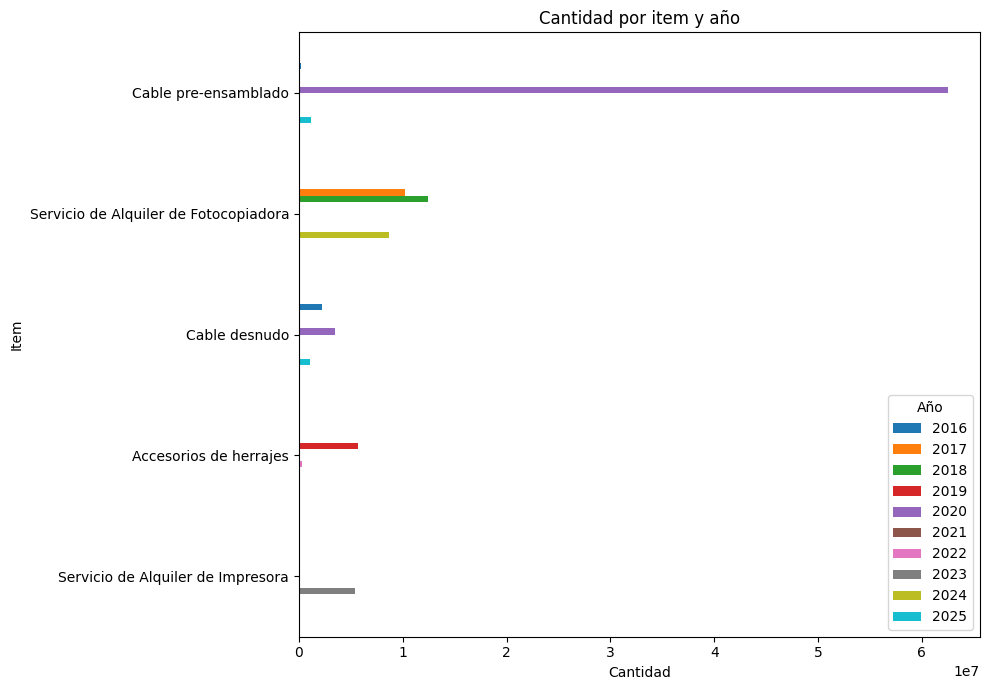

In [86]:
import numpy as np

# Pivotea: filas = item, columnas = year, valores = cantidad
tabla = dataset_cleared.pivot_table(index='item', columns='year_compiled', values='quantity', aggfunc='sum', fill_value=0)

# Tomamos los top 10 items según el total general
top_items = tabla.sum(axis=1).sort_values(ascending=False).head(5).index
tabla = tabla.loc[top_items]

tabla.plot(kind='barh', figsize=(10, 7))
plt.xlabel('Cantidad')
plt.ylabel('Item')
plt.title('Cantidad por item y año')
plt.legend(title='Año')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Es muy vago y requiere profundidad en un solo objeto

In [38]:
mask1 = dataset_cleared['item'].str.contains('Transformador de distribucion', case=False, na=False)
mask2 = ~dataset_cleared['item'].str.contains('Servicio', case=False, na=False)
#mask1 = dataset_cleared['item'].str.contains('Ampliacion de red electrica', case=False, na=False)
#mask1 = dataset_cleared['item'].str.contains('Servicio desmontaje y montaje de Sistemas electricos de Sub estaciones', case=False, na=False)

transformadores_ande = dataset_cleared[mask1 & mask2]
transformadores_ande.sample(10)

,date_awards,year_compiled,item,quantity,amount,currency
4645,2017-07-10T12:00:00-04:00,2022,Transformador de distribucion trifasico,18.0,43334000.0,PYG
22552,2019-08-30T12:00:00-04:00,2023,Transformador de distribucion trifasico,28.0,29090000.0,PYG
7,2022-10-26T12:00:00-04:00,2025,Transformador de distribucion trifasico,800.0,31482880.0,PYG
2228,2021-07-01T12:00:00-04:00,2024,Transformador de distribucion trifasico,36.0,29650000.0,PYG
2233,2021-07-01T12:00:00-04:00,2024,Transformador de distribucion trifasico,42.0,47701698.0,PYG
19881,2016-07-25T12:00:00-04:00,2019,Transformador de distribucion trifasico,36.0,40750000.0,PYG
1452,2018-07-05T12:00:00-04:00,2017,Transformador de distribucion trifasico,12.0,38500000.0,PYG
1611219,2025-09-26T00:00:00-04:00,2025,Transformador de distribucion trifasico,600.0,28790417.0,PYG
2249,2021-07-01T12:00:00-04:00,2024,Transformador de distribucion trifasico,24.0,62381000.0,PYG
2222,2021-07-01T12:00:00-04:00,2024,Transformador de distribucion trifasico,376.0,10711444.0,PYG


In [17]:
#ordenar
transformadores_ande = transformadores_ande.sort_values(by=["year_compiled", "item"])

print("Cantidad de registros de transformadores contratos de ANDE:", len(transformadores_ande))

Cantidad de registros de transformadores contratos de ANDE: 232


Tratar de obtener el grafico de todo lo obtenido

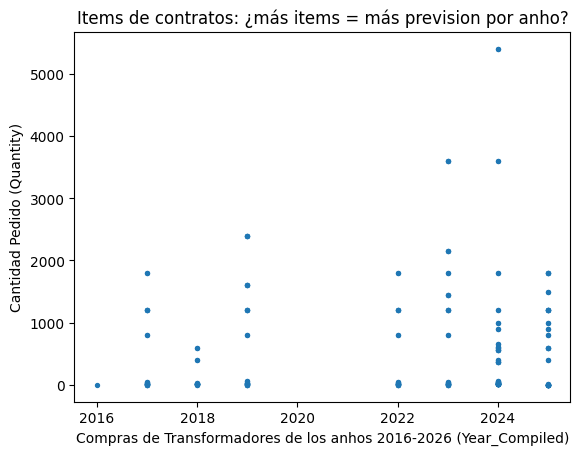

In [20]:
# Ejecutar esta celda (ya está completa): dibuja el primer gráfico del curso
import matplotlib.pyplot as plt

plt.scatter(transformadores_ande["year_compiled"], transformadores_ande["quantity"], s=8)
plt.xlabel("Compras de Transformadores de los anhos 2016-2026 (Year_Compiled)")
plt.ylabel("Cantidad Pedido (Quantity)")
plt.title("Items de contratos: ¿más items = más prevision por anho?")
plt.show()

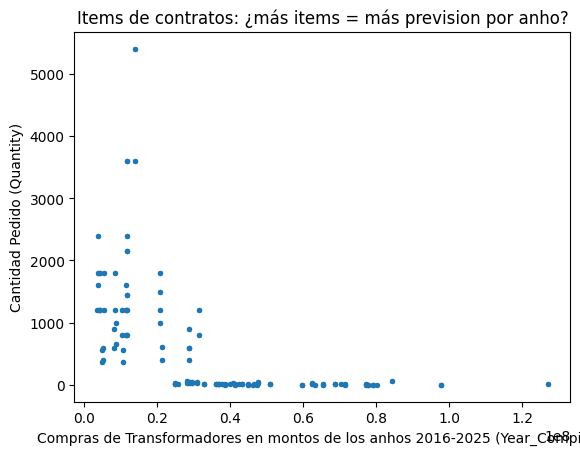

In [21]:
# Ejecutar esta celda (ya está completa): dibuja el primer gráfico del curso
import matplotlib.pyplot as plt

plt.scatter(transformadores_ande["amount"], transformadores_ande["quantity"], s=8)
plt.xlabel("Compras de Transformadores en montos de los anhos 2016-2025 (Year_Compiled)")
plt.ylabel("Cantidad Pedido (Quantity)")
plt.title("Items de contratos: ¿más items = más prevision por anho?")
plt.show()

In [22]:
# Completar aquí
n_faltantes = transformadores_ande["quantity"].isna().sum()
print("Cantidad de registros faltantes en la columna 'quantity':", n_faltantes)

Cantidad de registros faltantes en la columna 'quantity': 0


In [23]:
transformadores_ande.head()

,date_awards,year_compiled,item,quantity,amount,currency
501,2017-03-02T12:00:00-04:00,2016,Transformador de distribucion monofasico,4.0,80153250.0,PYG
1453,2018-07-05T12:00:00-04:00,2017,Transformador de distribucion monofasico,1200.0,3560000.0,PYG
1459,2018-07-05T12:00:00-04:00,2017,Transformador de distribucion monofasico,1800.0,3800000.0,PYG
1465,2018-07-05T12:00:00-04:00,2017,Transformador de distribucion monofasico,1200.0,3560000.0,PYG
1471,2018-07-05T12:00:00-04:00,2017,Transformador de distribucion monofasico,1800.0,3800000.0,PYG


Existen muchos valores con cantidades superiores a 3000

Con la informacion obtenida, retiramos los valores para visualizar el cambio

In [24]:
#mask1 = dataset_cleared['item'].str.contains('Transformador', case=False, na=False)
#mask2 = ~dataset_cleared['item'].str.contains('Servicio', case=False, na=False)

#transformadores_ande = dataset_cleared[mask1 & mask2]
#transformadores_ande = transformadores_ande[transformadores_ande["quantity"] <= 3000]
#transformadores_ande = transformadores_ande[transformadores_ande["quantity"] < 2]

transformadores_grouped = transformadores_ande.groupby(['item', 'year_compiled', 'currency'])['quantity'].sum().reset_index()
transformadores_grouped.head()

,item,year_compiled,currency,quantity
0,Transformador de distribucion monofasico,2016,PYG,4.0
1,Transformador de distribucion monofasico,2017,PYG,6000.0
2,Transformador de distribucion monofasico,2018,PYG,2000.0
3,Transformador de distribucion monofasico,2019,PYG,10400.0
4,Transformador de distribucion monofasico,2022,PYG,6000.0


Primer intento:
Generar un modelo de regresion para los datos reorganizados.

In [26]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


print("✓ Dataset: ", len(transformadores_grouped) ," filas cargadas.")
y = transformadores_grouped["quantity"]
X = transformadores_grouped[["year_compiled"]]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
modelo = LinearRegression()
modelo.fit(X_train, y_train)

datos_entrenamiento = len(X_train)
print("Datos de Entrenamiento = ", datos_entrenamiento)
print("✓ Modelo Terminado. R² =", round(modelo.score(X_test, y_test), 3))




✓ Dataset:  15  filas cargadas.
Datos de Entrenamiento =  10
✓ Modelo Terminado. R² = 0.326


Generamos una pequeña evaluación con datos de test para validar el proceso

In [27]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predicciones con lo que haya
# Crear DataFrame con el mismo nombre de columna que X_train
#X_nuevo = pd.DataFrame({"year_compiled": [2026, 2027, 2028]})
y_pred = modelo.predict(X_test)


# evaluamos
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("===== MÉTRICAS DEL MODELO =====")
print(f"MAE  (Error Absoluto Medio): {mae:.3f}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.3f}")
print(f"R²   (Coeficiente de Determinación): {r2:.3f}")

===== MÉTRICAS DEL MODELO =====
MAE  (Error Absoluto Medio): 7804.854
RMSE (Raíz del Error Cuadrático Medio): 8413.171
R²   (Coeficiente de Determinación): 0.326


Verificamos la gráfica para visibilizar el proceso

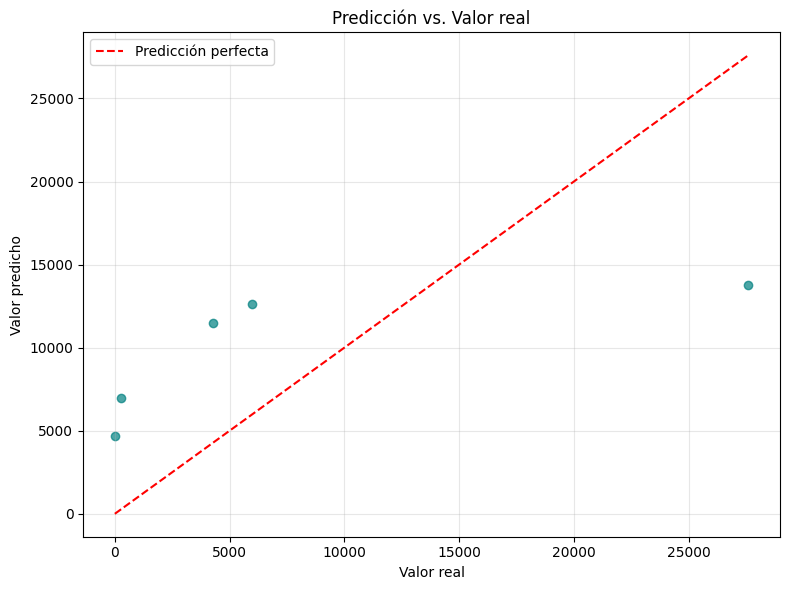

In [28]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, modelo.predict(X_test), color='teal', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', label='Predicción establecida sobre test')
plt.xlabel('Valor real')
plt.ylabel('Valor predicho')
plt.title('Predicción vs. Valor real')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Agregar una validacion pero considerando que tenemos pocos registros... puede ser bajo el rendimiento en especifico para el test

In [29]:
from sklearn.model_selection import cross_val_score

# Completar aquí
notas = cross_val_score(LinearRegression(), X, y, cv=5)
print(notas)

nota_honesta = round(notas.mean(), 2)

[ -0.24214268  -7.9762253   -9.71366636  -0.4603905  -11.16851335]


De lo evaluado y con los datos, es muy posible que se tenga muy poco aprendizaje en base al resumen de los datos y las bajas calificaciones.

## Segundo Round:
- Ya hemos probado validez con los datos, pero tomemos el ítem de mayor volumen de pedidos
- Arriesguemos tomando los datos de las fechas más largas en el detalle
- Incluso empleemos eso como dato para el año o sólo esa fecha para el modelo

In [51]:
mask1 = dataset_cleared['item'].str.contains('Cable', case=False, na=False)
mask2 = ~dataset_cleared['item'].str.contains('Servicio', case=False, na=False)
mask3 = ~dataset_cleared['item'].str.contains('Montaje', case=False, na=False)
mask4 = ~dataset_cleared['item'].str.contains('Terminación', case=False, na=False)

cables_ande = dataset_cleared[mask1 & mask2 & mask3 & mask4]
cables_ande.sample(10)

,date_awards,year_compiled,item,quantity,amount,currency
8566,2018-07-16T12:00:00-04:00,2024,Cable de fibra optica,1.0,59722.0,USD
18515,2018-02-12T12:00:00-04:00,2024,Cable de cobre,1.0,116580.0,USD
5181,2019-10-31T12:00:00-04:00,2022,Cable Unipolar,1.0,698460.0,USD
5164,2019-10-31T12:00:00-04:00,2022,Cable desnudo,1.0,200621.0,USD
1627500,2025-12-02T17:28:07-04:00,2025,Cable pre-ensamblado,26131.0,3.0,PYG
18578,2019-12-03T12:00:00-04:00,2020,Cable Unipolar,48360.0,1514.0,PYG
18579,2019-12-03T12:00:00-04:00,2020,Cable Unipolar,57600.0,58064.0,PYG
1627486,2023-12-12T22:55:23-04:00,2025,Cable de cobre,3250.0,6.0,PYG
18676,2019-12-03T12:00:00-04:00,2020,Cable desnudo,2400.0,42202.0,PYG
18697,2019-12-03T12:00:00-04:00,2020,Cable Unipolar,600.0,21044.0,PYG


Como se visibiliza hay muchos datos de fecha con tiempo y no estructura normalizada que debería formatearse.

In [75]:
# Crear la nueva columna con formato DD-MM-AAAA
#cables_ande['date_process'] = pd.to_datetime(cables_ande['date_awards'], errors='coerce').dt.date
#cables_ande_grouped = cables_ande.groupby(['item', 'year_compiled', 'currency', 'date_process'])['quantity'].sum().reset_index()

#ordenar
#cables_ande_grouped = cables_ande_grouped.sort_values(by=["date_process", "item"])
#cables_ande_grouped ['date_process'] = cables_ande_grouped ['date_process'].apply(pd.Timestamp.timestamp)

#Y usar year_frac en vez de (o además de) year_compiled, ya que:
#Es continua (mejor para regresión lineal que categorías discretas)
#Captura la tendencia temporal real, no solo el año "compilado"
#Si agrupás por year_frac con más granularidad (por trimestre, por ejemplo), podés ver tendencias intra-año

cables_ande['date_awards'] = pd.to_datetime(cables_ande['date_awards'])
#cables_ande['year_extracted'] = cables_ande['date_awards'].dt.year
cables_ande['year_frac'] = cables_ande['date_awards'].dt.year + (cables_ande['date_awards'].dt.dayofyear - 1) / 365
cables_ande_grouped = cables_ande.groupby(['item', 'year_frac', 'currency', 'date_awards'])['quantity'].sum().reset_index()
cables_ande_grouped.head()
cables_ande_grouped = cables_ande_grouped.sort_values(by=["year_frac", "item"])

print("Cantidad de registros de cables en contratos de ANDE:", len(cables_ande_grouped))

Cantidad de registros de cables en contratos de ANDE: 297


/tmp/ipykernel_1848/847408076.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cables_ande['date_awards'] = pd.to_datetime(cables_ande['date_awards'])
/tmp/ipykernel_1848/847408076.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cables_ande['year_frac'] = cables_ande['date_awards'].dt.year + (cables_ande['date_awards'].dt.dayofyear - 1) / 365


In [64]:
cables_ande_grouped.head()

,item,year_frac,currency,date_awards,quantity
125,Cable galvanizado de acero,2015.898630,USD,2015-11-25 12:00:00-04:00,3.0
135,Cable pre-ensamblado,2015.898630,USD,2015-11-25 12:00:00-04:00,3.0
166,Cable protegido,2015.898630,USD,2015-11-25 12:00:00-04:00,3.0
136,Cable pre-ensamblado,2016.134247,PYG,2016-02-19 12:00:00-04:00,6000.0
56,Cable de cobre,2016.243836,PYG,2016-03-30 12:00:00-04:00,32600.0


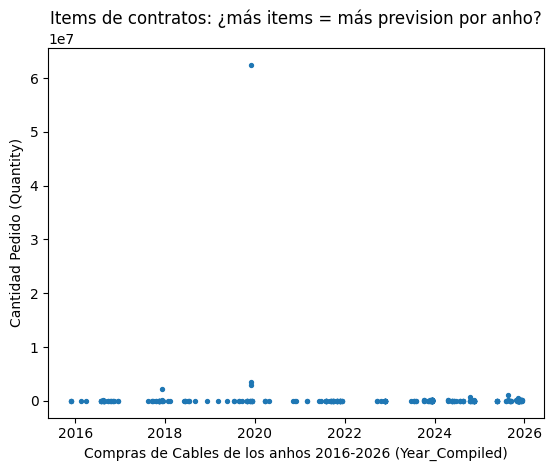

In [76]:
# Ejecutar esta celda (ya está completa): dibuja el primer gráfico del curso
import matplotlib.pyplot as plt

plt.scatter(cables_ande_grouped["year_frac"], cables_ande_grouped["quantity"], s=8)
plt.xlabel("Compras de Cables de los anhos 2016-2026 (Year_Compiled)")
plt.ylabel("Cantidad Pedido (Quantity)")
plt.title("Items de contratos: ¿más items = más prevision por anho?")
plt.show()

In [80]:
cables_ande_grouped = cables_ande_grouped[cables_ande_grouped["quantity"] <= 5000]

Conformamos un siguiente modelo tomando la estructura de las fechas

In [82]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


print("✓ Dataset: ", len(cables_ande_grouped) ," filas cargadas.")
y = cables_ande_grouped["quantity"]
X = cables_ande_grouped[["year_frac"]]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
modelo = LinearRegression()
modelo.fit(X_train, y_train)

datos_entrenamiento = len(X_train)
print("Datos de Entrenamiento = ", datos_entrenamiento)
print("✓ Modelo Terminado. R² =", round(modelo.score(X_test, y_test), 3))

✓ Dataset:  177  filas cargadas.
Datos de Entrenamiento =  123
✓ Modelo Terminado. R² = 0.029


Visibilizamos la gráfica para ver el proceso

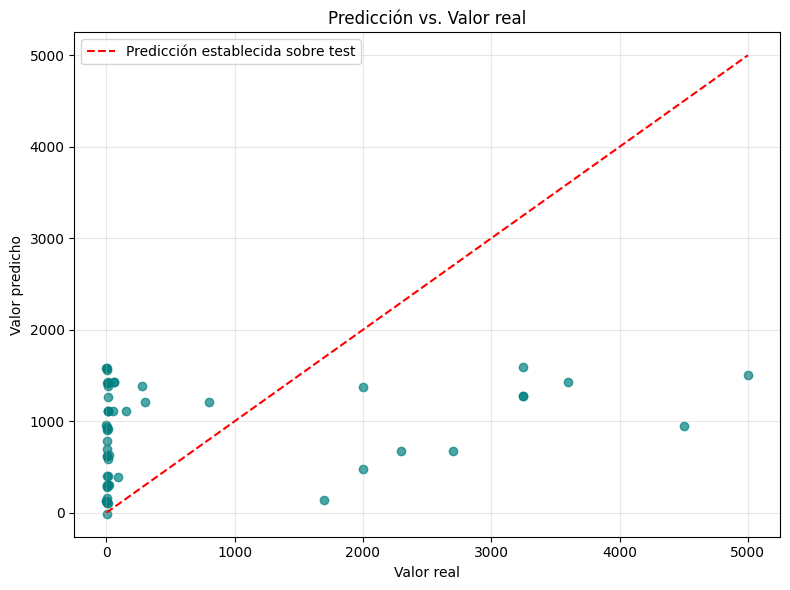

In [83]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, modelo.predict(X_test), color='teal', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', label='Predicción establecida sobre test')
plt.xlabel('Valor real')
plt.ylabel('Valor predicho')
plt.title('Predicción vs. Valor real')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [101]:
mask1 = dataset_cleared['item'].str.contains('Transformador', case=False, na=False)
#mask2 = dataset_cleared['item'].str.contains('Servicio', case=False, na=False)
#mask1 = dataset_cleared['item'].str.contains('Ampliacion de red electrica', case=False, na=False)
#mask1 = dataset_cleared['item'].str.contains('Servicio desmontaje y montaje de Sistemas electricos de Sub estaciones', case=False, na=False)

serv_transformadores_ande = dataset_cleared[mask1 & mask2]
serv_transformadores_ande.sample(10)

,date_awards,year_compiled,item,quantity,amount,currency
6781,2020-01-03T12:00:00-04:00,2025,Servicio de instalacion de transformador,1.0,95.0,USD
9196,2020-01-03T12:00:00-04:00,2025,Servicio de instalacion de transformador,1.0,3620.0,USD
3763,2019-10-10T12:00:00-04:00,2025,Servicio de instalacion de transformador,1.0,16920.0,USD
1623730,2019-11-27T12:00:00-04:00,2025,Servicio de instalacion de transformador,1.0,1300.0,USD
18989,2017-12-11T12:00:00-04:00,2019,Servicio de instalacion de transformador,1.0,89052.0,USD
8788,2020-01-03T12:00:00-04:00,2025,Servicio de instalacion de transformador,1.0,3008.0,USD
17197,2019-10-23T12:00:00-04:00,2019,Servicio de instalacion de transformador,1.0,959400.0,PYG
7660,2020-01-03T12:00:00-04:00,2025,Servicio de instalacion de transformador,1.0,19738.0,USD
8111,2020-01-03T12:00:00-04:00,2025,Servicio de instalacion de transformador,1.0,2850.0,USD
1623547,2019-11-27T12:00:00-04:00,2025,Servicio de instalacion de transformador,1.0,1700.0,USD


In [102]:
print("Cantidad de registros relacionados con servicios en contratos de ANDE:", len(serv_transformadores_ande))

Cantidad de registros relacionados con servicios en contratos de ANDE: 655


adf

In [91]:
serv_transformadores_ande['date_awards'] = pd.to_datetime(serv_transformadores_ande['date_awards'])
serv_transformadores_ande['year_frac'] = serv_transformadores_ande['date_awards'].dt.year + (serv_transformadores_ande['date_awards'].dt.dayofyear - 1) / 365
serv_transformadores_ande = serv_transformadores_ande.sort_values(by=["year_frac", "item"])
#servicios_ande_grouped = serv_transformadores_ande.groupby(['item', 'year_frac', 'currency', 'date_awards'])['quantity'].sum().reset_index()
#servicios_ande_grouped.head()
#servicios_ande_grouped_grouped = servicios_ande_grouped.sort_values(by=["year_frac", "item"])

print("Cantidad de registros relacionados con servicios en contratos de ANDE:", len(serv_transformadores_ande))

Cantidad de registros relacionados con servicios en contratos de ANDE: 3173


/tmp/ipykernel_1848/2846672774.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  serv_transformadores_ande['date_awards'] = pd.to_datetime(serv_transformadores_ande['date_awards'])
/tmp/ipykernel_1848/2846672774.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  serv_transformadores_ande['year_frac'] = serv_transformadores_ande['date_awards'].dt.year + (serv_transformadores_ande['date_awards'].dt.dayofyear - 1) / 365


In [98]:
resumen_por_año = serv_transformadores_ande.groupby('year_compiled').agg(
    total_items_distintos=('item', 'nunique'),   # cantidad de items únicos ese año
    total_pedidos=('item', 'count'),               # cantidad de registros/pedidos
    cantidad_total=('quantity', 'sum'),
    monto_total=('amount', 'sum')
).reset_index()

print(resumen_por_año)

   year_compiled  total_items_distintos  total_pedidos  cantidad_total  \
0           2018                      1            127           127.0   
1           2019                      1            119           119.0   
2           2022                      1            100           100.0   
3           2023                      1             83            83.0   
4           2024                      1            874           874.0   
5           2025                      1           1870          1870.0   

    monto_total  
0  1.106482e+08  
1  1.386401e+08  
2  3.148396e+06  
3  1.509491e+06  
4  1.059903e+10  
5  4.827966e+09  


In [103]:
tabla_montos = serv_transformadores_ande.pivot_table(
    index='item',
    columns='year_compiled',
    values='amount',
    aggfunc='sum',
    fill_value=0
)
print(tabla_montos)

year_compiled                                 2018        2019       2022  \
item                                                                        
Servicio de instalacion de transformador  130119.0  51639289.0  1294335.0   

year_compiled                                 2023          2024         2025  
item                                                                           
Servicio de instalacion de transformador  156790.0  2.378217e+09  894734583.0  


adfafd

In [96]:
print("✓ Dataset: ", len(serv_transformadores_ande) ," filas cargadas.")
y = serv_transformadores_ande["amount"]
X = serv_transformadores_ande[["year_frac"]]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
modelo = LinearRegression()
modelo.fit(X_train, y_train)

datos_entrenamiento = len(X_train)
print("Datos de Entrenamiento = ", datos_entrenamiento)
print("✓ Modelo Terminado. R² =", round(modelo.score(X_test, y_test), 3))

✓ Dataset:  3173  filas cargadas.
Datos de Entrenamiento =  2221
✓ Modelo Terminado. R² = 0.076


agrad

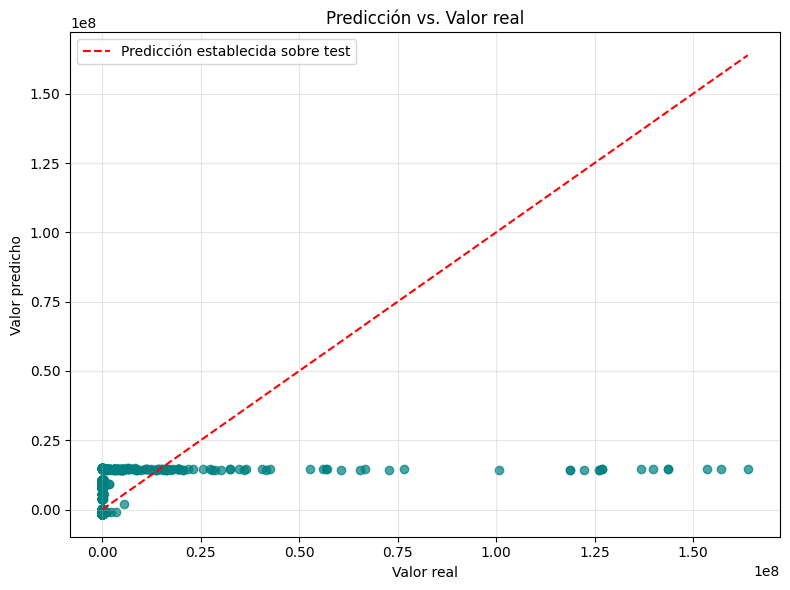

In [97]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, modelo.predict(X_test), color='teal', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', label='Predicción establecida sobre test')
plt.xlabel('Valor real')
plt.ylabel('Valor predicho')
plt.title('Predicción vs. Valor real')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()